# Monitoring Coastal Erosion Along Ghana's Coastline

* **Products used:**  
[ls8_sr](https://explorer.digitalearth.africa/ls8_sr), [ls9_sr](https://explorer.digitalearth.africa/ls9_sr)  

## Background
Over 40% of the world’s population lives within 100 km of the coastline.
With a coastline of 550 kilometres and a quarter of its population living by the sea, Ghana is particularly affected by coastal erosion.


However, coastal environments are constantly changing, with erosion and coastal change presenting a major challenge to valuable coastal infrastructure and important ecological habitats. By 2017 in Ghana, nearly eighty houses and a school building had been destroyed, and more than 300 inhabitants displaced. Farmlands and plantations were washed away, and the local fishermen lost their livelihoods. The situation has only worsened in the last three years, with the shoreline retreating several metres inland in some places, and by as much as 100 metres in others. [Source](https://courier.unesco.org/en/articles/ghanas-coastline-swallowed-sea.html).

Up-to-date data on coastal change and erosion is essential for coastal managers to be able to identify and minimise the impacts of coastal change and erosion in Ghana.  

Monitoring coastlines using field surveys can be challenging and hazardous, particularly at national scale.
Aerial photography and LiDAR can be used to monitor coastal change, but this is often expensive and requires many repeated flights over the same areas of coastline to build up an accurate history of how the coastline has changed across time.

Imagery from satellites such as the NASA/USGS Landsat, Copernicus Sentinel-1/2 constellations is available for free for the entire planet, making satellite imagery a powerful and cost-effective tool for monitoring coastlines and rivers at regional or national scale.

### DE Africa use case
The usefulness of optical imagery such as [Landsat](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_C2_SR_specs.html) and [Sentinel-2](https://docs.digitalearthafrica.org/en/latest/data_specs/Sentinel-2_Level-2A_specs.html) in the coastal zone can be affected by the presence of clouds, sun-glint over water, poor water quality (e.g. sediment), and the influence of tides. The effect of these factors can be reduced by combining individual noisy images into cleaner "summary" or composite layers, and filtering the data to focus only on images taken at certain tidal conditions (e.g. mid-tide). These clean, tidally-constrained composite images can then be used to identify and extract the precise boundary between water and land. This allows us to extract accurate shorelines that can be compared across time to reveal hotspots of erosion and coastal change.

Since radar measurement is sensitive to surface roughness, moisture content, and viewing geometry, the shoreline delineation can be affected by surface conditions such as breaking waves. Our temporal composite approach reduces noise caused by temporary conditions but shorelines mapped by radar may still be biased compared to shoreline identified in optical imagery. For example, smooth and flat beaches may be mistaken for water when they exhibit extremely low backscatter values.

### Description

In this example, we use a simplified version of the [DE Africa Coastlines](https://github.com/digitalearthafrica/deafrica-coastlines.git) method to combine time series data with image compositing and tide filtering techniques to accurately map shorelines across time, and identify changes. For a selected area of interest, data from Landsat, Sentinel-2 or Sentinel-1 are selected based on availability.

Following steps are demonstrated:
1. Query and load Landsat, Sentinel-2, or Sentinel-1 time-series data for a selected area of interest.
2. Generate annual composite images using image compositing and tide-filtering approaches.
3. Extract water–land boundaries to produce shoreline vectors for each year.
4. Calculate rates of coastal change and identify hotspots of erosion or accretion.
5. Compute the change in shoreline, relative to a baseline year (2015).

### Getting started
**To run this analysis**, run all the cells in the notebook, starting with the "Load packages" cell.

**After finishing the analysis**, return to the "Analysis parameters" cell, modify some values (e.g. choose a different location or time period to analyse) and re-run the analysis.
There are additional instructions on modifying the notebook at the end.

To support shoreline extraction and coastal-change calculations, we will install tools from the DE Africa Coastlines repository. These utilities include functions for compositing, waterline detection, and linear regression of shoreline change.

In [1]:
pip install -q git+https://github.com/digitalearthafrica/deafrica-coastlines.git@S2_test --disable-pip-version-check

Note: you may need to restart the kernel to use updated packages.


## Load packages and functions

The functions in **“Coastal_functions.py”** implement a structured workflow for coastal change analysis using satellite data. They handle data loading and preprocessing (including tidal filtering using models such as EOT20), compute water indices for shoreline detection, generate annual composite datasets, and extract subpixel shoreline contours. Building on these outputs, the functions quantify shoreline dynamics by calculating movement rates, regressions, and relative changes over time, and also support visualization through animated shoreline maps. Collectively, they enable consistent, tide-corrected mapping and analysis of coastal evolution from multi-temporal Earth observation data.

**Load Needed Packages**

In [2]:
import matplotlib.pyplot as plt           # Main plotting library
import warnings
warnings.filterwarnings("ignore")         # Suppress warnings for cleaner output
import rioxarray                          # This "activates" the .rio accessor for xarray objects

# Coastline analysis tools
from coastlines.raster import load_tidal_subset, tide_cutoffs
from coastlines.vector import annual_movements, calculate_regressions, points_on_line

import numpy as np
import pandas as pd                       # Table/data handling
import matplotlib.pyplot as plt           # Main plotting library
from matplotlib.animation import FuncAnimation          # For animated plots
from IPython.display import Image         # For displaying animation

from scipy.stats import linregress        # For Linear regression analysis

# Load Digital Earth Africa Tools
import datacube                                                # Core Open Data Cube interface
import Coastal_functions as cf                                 # loads funtions
from deafrica_tools.areaofinterest import define_area          # Define AOI
from deafrica_tools.dask import create_local_dask_cluster      # Set up Dask cluster
from odc.geo.geom import Geometry                              # ODC geometry tools
import geopandas as gpd                                        # Vector data handling
from deafrica_tools.datahandling import (load_ard,
                                         load_best_available_ds,
                                         preprocess_s1)        # Load and process datasets
from deafrica_tools.bandindices import calculate_indices       # Compute spectral indices
from deafrica_tools.spatial import subpixel_contours           # Extract subpixel contours

from deafrica_tools.plotting import display_map, rgb, xr_animation  # Plotting helpers

# EO tides model for estimating water levels per pixel
from eo_tides.eo import pixel_tides


### Set up a Dask cluster

Dask can be used to better manage memory use down and conduct the analysis in parallel.
For an introduction to using Dask with Digital Earth Africa, see the [Dask notebook](../Beginners_guide/08_Parallel_processing_with_dask.ipynb).

>**Note**: We recommend opening the Dask processing window to view the different computations that are being executed; to do this, see the *Dask dashboard in DE Africa* section of the [Dask notebook](../Beginners_guide/08_parallel_processing_with_dask.ipynb).

To use Dask, set up the local computing cluster using the cell below.

### Set up a Dask cluster

The line initializes a new Datacube instance, creating a connection to the Open Data Cube (ODC) database so the script can access indexed satellite datasets such as Landsat and Sentinel-2. It names the session `"Blekusu_Analysis"`, which helps with logging, tracking, and metadata management. This object is essential because it enables all subsequent data queries—functions like `dc.load()` rely on this instance to retrieve imagery and perform other datacube operations.

In [3]:
# 1. Setup Environment
client = create_local_dask_cluster(return_client=True)
dc = datacube.Datacube(app="Blekusu_Analysis")


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jjagyekum@gmail.com/proxy/8787/status,
Dashboard: /user/jjagyekum@gmail.com/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 26.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43645,Workers: 0
Dashboard: /user/jjagyekum@gmail.com/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43957,Total threads: 4
Dashboard: /user/jjagyekum@gmail.com/proxy/42665/status,Memory: 26.21 GiB
Nanny: tcp://127.0.0.1:45581,


### Analysis parameters

The following cell set important parameters for the analysis:

* `lat`: The central latitude to analyse (e.g. `5.989996`).
* `lon`: The central longitude to analyse (e.g. `1.036321`).
* `buffer`: The number of square degrees to load around the central latitude and longitude. For reasonable loading times, set this as `0.1`.
* `time_range`: The date range to analyse (e.g. `('2015', '2024')`)
* `time_step`: This parameter allows us to choose the length of the time periods we want to compare: e.g. shorelines for each year, or shorelines for each six months etc. `1Y` will generate one coastline for every year in the dataset; `2Y` will produce a coastline for every two years, etc.
* `filter_size`: An integer number defining the size of the speckle filter window used for Sentinel-1. As we will use temporal composites, which will help remove speckle noise, we recommend setting this filter size as None to disable speckle filtering, or a very small value (e.g. 2) to avoid significant degradation of spatial resolution.  
* `s1_orbit_filtering`: A boolean value defining whether to filter Sentinel-1 observations by satellite orbit. When this is set to True, a per-pixel filtering will be applied to keep only observations acquired in the orbit with higher frequency. This parameter is set to False by default, which means observations from both descending and ascending orbits will be returned.  

### Select location
To define the area of interest:

1. We specify the latitude, longitude, and buffer. This method requires you to input the central latitude, central longitude, and the buffer value in square degrees around the center point you want to analyze. For example, `lat = 5.989996`, `1.036321`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates.
The example explores coastal change in Blekusu.

In [4]:
# 2. Define Area
aoi = define_area(lat=5.989996, lon=1.036321, buffer=0.01)

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

# Set the range of dates for the analysis, time step and tide range
time_range = ("2015", "2024") # Define time range

### Visualizing selected AOI
An interactive map is displayed using the coordinate ranges. Participants can zoom and inspect the AOI and capture lat/lon values through clicks. This helps to visually confirm the spatial extent before running heavy queries.


In [5]:
# Display an interactive map
display_map(x=lon_range, y=lat_range)

### Processing Coastal Data (loading, tide filtering, and MNDWI)

The `process_coastal_data` function in `Coastal_funtions.py` provides a preprocessing pipeline for coastal remote sensing analysis by systematically integrating data acquisition, tidal normalization, and feature derivation. It begins by:
* loading the most suitable satellite dataset (e.g., Landsat) for a specified spatial extent, time range, and temporal aggregation interval using `load_best_available_ds` which evaluates data availability and quality. If the `product` is specified, the function would only load most suitable datasets from that product only. In this part, we will specify only Landsat.
* The function then augments the dataset with modeled tidal heights using the `EOT20` tidal model and applies a tidal filtering step based on defined cutoff thresholds, retaining only observations within a consistent tidal range to minimise variability in shoreline position. Based on the entire time-series of tide heights, we can compute the max and min satellite-observed tide height for each pixel, then calculate tide cutoffs used to restrict our data to satellite observations centred over mid-tide (0 m above mean sea level, a.m.s.l.) using the `tide_cutoffs` function.
* Filtering: Using the modelled tide values, this step keeps only the observations falling within a mid‑tide range (typically around 0 m a.m.s.l. ). Timestamps with no valid pixels are dropped.
* After filtering, the function derives a water-sensitive variable tailored to the sensor type: for optical imagery, it computes the Modified Normalized Difference Water Index (`MNDWI`) to enhance the contrast between land and water, while for radar data it applies preprocessing to Sentinel-1 backscatter to improve water detection. By combining these steps, the function outputs a temporally structured, tidally-consistent dataset and a corresponding analysis variable, providing a robust foundation for subsequent shoreline extraction and coastal change assessment.

The `MNDWI` uses the ratio of green and Shortwave-Infrared (SWIR) radiation to identify the presence of water [(Xu 2006)](https://doi.org/10.1080/01431160600589179).
The formula is:

$$
\begin{aligned}
\text{MNDWI} &= \frac{(\text{Green} - \text{SWIR})}{(\text{Green} + \text{SWIR})}
\end{aligned}
$$

where `Green` is the green band and `SWIR` is the SWIR band.



In [6]:
# Call the function (assuming you've defined dc, ranges, etc.)
ds_selected, var = cf.process_coastal_data(dc, lat_range, lon_range, time_range, product="ls")

No resolution pre-set, using default resolutions for individual products...

Pre-selected product: Landsat
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr
    ls9_sr
Counting good quality pixels for each time step


/opt/venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 152 out of 245 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 152 time steps as a dask array
Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with EOT20
Reprojecting tides into original resolution


### Visualizing a timestep
Here we plot an example image at the selected location at a given timestamp. White areas indicate where clouds or other invalid pixels in the image have been masked.


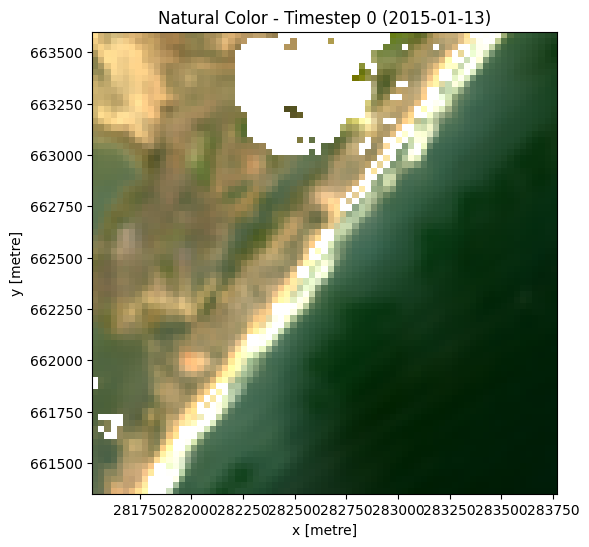

In [7]:
# Visualize the fifth available timestep (index 4)
# We use percentile_stretch to make the colors pop
rgb(ds_selected, index=4, percentile_stretch=[0.02, 0.98])
plt.title(f"Natural Color - Timestep 0 ({ds_selected.time.values[0].astype('datetime64[D]')})")
plt.show()

In [8]:
# Shut down Dask client now that we have processed the data we need
client.close()

## Extract shorelines and calculate rates of coastal change
### Extract shorelines from imagery

We are now extracting an annual shoreline from the tidally-filtered summary images. The workflow first defines a threshold to separate land and water based on the selected variable (`var`). For optical imagery (Landsat and Sentinel-2), where the Modified Normalized Difference Water Index (MNDWI) is used, a fixed threshold of 0 is applied. For radar imagery (Sentinel-1, using VH backscatter), a data-driven threshold is computed using the `threshold_minimum` function. This method evaluates the distribution of backscatter values (excluding NaNs), smooths the histogram to identify two dominant peaks (typically representing land and water), and selects the minimum value between them as the optimal threshold.

In [9]:
# Determine threshold based on the 'var' returned by the function
# MNDWI is usually 0, while SAR (vh) usually needs a data-driven threshold
if var == "MNDWI":
    threshold = 0.0
else:
    # Compute data-driven threshold for Sentinel-1 (SAR)
    threshold = threshold_minimum(
        ds_selected[var].values[~np.isnan(ds_selected[var].values)]
    )
    print(f"Calculated dynamic SAR threshold: {threshold:.2f}")

## Resampling to Annual Composites

The dataset is then resampled to annual composites by taking the median value for each year, reducing noise and temporal variability. The time dimension is converted to a “year” coordinate to support temporal analysis.

Finally, the `subpixel_contours` function is used to delineate the shoreline for each year. This function traces a contour along the specified threshold value at subpixel precision, producing a vector dataset of shoreline positions. Each extracted contour corresponds to a single year, resulting in a GeoJSON file containing annual shoreline lines that can be used to analyse coastal change over time.


In [10]:
time_step = "1Y"

ds_summaries = ds_selected[[var]].resample(time="1Y").median("time").compute()
# Rename time attribute as year
ds_summaries["time"] = ds_summaries.time.dt.year
ds_summaries = ds_summaries.rename(time="year")

# 3. Extract annual shoreline contours and save to a GEOJSON file
# Note: Ensure you have already created 'ds_summaries' from 'ds_selected'
contour_gdf = subpixel_contours(
    da=ds_summaries[var],
    z_values=threshold,
    dim="year",
    crs=ds_summaries.geobox.crs,
    output_path=f"annual_shorelines_{var}.geojson",
    min_vertices=15,
)

contour_gdf = contour_gdf.set_index("year")
# Preview
contour_gdf

Operating in single z-value, multiple arrays mode
Writing contours to annual_shorelines_MNDWI.geojson


,geometry
year,
2015,"MULTILINESTRING ((283063.175 663585, 283050.93..."
2016,"MULTILINESTRING ((283071.196 663585, 283065 66..."
2017,"MULTILINESTRING ((283067.255 663585, 283065 66..."
2018,"MULTILINESTRING ((283062.682 663585, 283040.89..."
2019,"MULTILINESTRING ((283074.099 663585, 283065 66..."
2020,"MULTILINESTRING ((283065.966 663585, 283065 66..."
2021,"MULTILINESTRING ((283064.684 663585, 283041.64..."
2022,"MULTILINESTRING ((282763.942 663585, 282735 66..."
2023,"MULTILINESTRING ((281659.967 663585, 281685 66..."


### Plot resampled shorelines on an interactive map
The next cell provides an interactive map with an overlay of the shorelines identified in the previous cell. Run it to view the map (this step can take **several minutes to load** if the study area is large).

Zoom in to the map below to explore the resulting set of shorelines.
Older shorelines are coloured in black, and more recent shorelines in yellow.
Hover over the lines to see the time period for each shoreline printed above the map.
Using this data, we can easily identify areas of coastline or rivers that have changed significantly over time, or areas that have remained stable over the entire time period.


In [11]:
# Plot shorelines on interactive map
bounds = np.arange(2015, 2024, 1)

contour_gdf.reset_index().explore(
    column="year",
    cmap="inferno",
    categorical=True,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="ESRI WorldImagery",
)

## Calculate rates of coastline change
To identify parts of the coastline that are changing rapidly, we can use the annual shoreline data (*contour_gdf*) to calculate rates of coastal change in metres per year.
This can be particularly useful to reveal hotspots of coastal retreat (e.g. erosion), or hotspots of coastal growth.

To do this, we first need to create a set of evenly spaced points at every 20 metres along the most recent shoreline in our dataset.
These points will be used to plot rates of coastal change across our study area.

<Axes: >

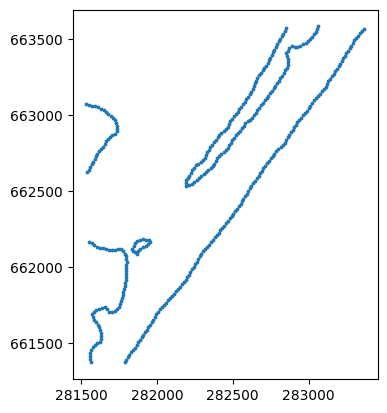

In [12]:
# Extract points at every 20 metres along the baseline (most recent shoreline)
points_gdf = points_on_line(contour_gdf, index=2015, distance=20)
points_gdf.plot(markersize=3)

Now that we have a set of modelling points, we can measure distances from each of the points to each annual shoreline.
This gives us a table of distances, where negative values (e.g. `-6.5`) indicate that an annual shoreline was located inland of our points, and positive values (e.g. `2.3`) indicate a shoreline was located towards the ocean. Because our points were created along our baseline (2015) shoreline, distances for 2015 will always have a distance of 0 m.

In [13]:
# For each 20 m-spaced point, calculate the distance from
# the most recent 2023 shoreline to each other annual shoreline
# in the datasets.
points_gdf = annual_movements(
    points_gdf,
    contours_gdf=contour_gdf,
    yearly_ds=ds_summaries,
    baseline_year=2015,
    water_index=var,
)
points_gdf

,geometry,dist_2015,dist_2016,dist_2017,dist_2018,dist_2019,dist_2020,dist_2021,dist_2022,dist_2023,dist_2024,angle_mean,angle_std
0,POINT (283063.175 663585),0.0,-6.19,-3.02,0.49,-8.19,-2.18,-1.20,-1.02,-11.57,-10.71,128,20
1,POINT (283055.617 663566.483),0.0,-1.01,1.65,5.17,-2.57,1.24,4.09,2.10,-6.60,-4.21,129,15
2,POINT (283046.194 663549.06),0.0,1.81,4.15,7.74,0.12,2.76,6.87,3.34,-4.86,-1.19,126,16
3,POINT (283033.747 663533.405),0.0,1.31,3.02,5.00,-2.03,1.20,3.95,1.10,-7.96,-3.24,124,16
4,POINT (283022.101 663517.165),0.0,2.45,3.16,3.99,-3.05,0.98,3.04,-0.41,-8.66,-3.52,131,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,POINT (281562.354 661455.29),0.0,2.51,2.15,1.66,-14.63,-13.00,-10.67,-11.25,-2.61,5.84,115,19
380,POINT (281559.474 661435.523),0.0,5.50,2.56,1.74,-11.33,-8.93,-7.68,-10.19,-1.16,6.00,104,19
381,POINT (281558.904 661415.668),0.0,6.40,2.76,2.08,-10.03,-7.58,-6.21,-9.35,-1.03,5.11,83,19
382,POINT (281560.816 661395.76),0.0,5.02,3.02,2.90,-10.25,-8.73,-5.71,-8.52,-2.54,4.51,83,19


Finally, we can calculate annual rates of coastal change (in metres per year) using linear regression.
This will add new columns to our table:

* `rate_time`: Annual rates of change (in metres per year) calculated by linearly regressing annual shoreline distances against time (excluding outliers; see `outl_time`). Negative values indicate retreat and positive values indicate growth.
* `sig_time`: Significance (p-value) of the linear relationship between annual shoreline distances and time. Small values (e.g. p-value < 0.01 or 0.05) may indicate a coastline is undergoing consistent coastal change through time.
* `se_time`: Standard error (in metres) of the linear relationship between annual shoreline distances and time. This can be used to generate confidence intervals around the rate of change given by rate_time (e.g. 95% confidence interval = `se_time * 1.96`)
* `outl_time`: Individual annual shoreline are noisy estimators of coastline position that can be influenced by environmental conditions (e.g. clouds, breaking waves, sea spray) or modelling issues (e.g. poor tidal modelling results or limited clear satellite observations). To obtain reliable rates of change, outlier shorelines are excluded using a robust Median Absolute Deviation outlier detection algorithm, and recorded in this column.

In [14]:
# Calculate rates of change using linear regression
points_gdf = calculate_regressions(points_gdf=points_gdf, contours_gdf=contour_gdf)

#display the contents of points_gdf
points_gdf

,rate_time,sig_time,se_time,outl_time,dist_2015,dist_2016,dist_2017,dist_2018,dist_2019,dist_2020,dist_2021,dist_2022,dist_2023,dist_2024,angle_mean,angle_std,geometry
0,-0.746,0.137,0.452,,0.0,-6.19,-3.02,0.49,-8.19,-2.18,-1.20,-1.02,-11.57,-10.71,128,20,POINT (283063.175 663585)
1,-0.450,0.291,0.398,,0.0,-1.01,1.65,5.17,-2.57,1.24,4.09,2.10,-6.60,-4.21,129,15,POINT (283055.617 663566.483)
2,-0.372,0.402,0.421,,0.0,1.81,4.15,7.74,0.12,2.76,6.87,3.34,-4.86,-1.19,126,16,POINT (283046.194 663549.06)
3,-0.628,0.144,0.387,,0.0,1.31,3.02,5.00,-2.03,1.20,3.95,1.10,-7.96,-3.24,124,16,POINT (283033.747 663533.405)
4,-0.764,0.073,0.370,,0.0,2.45,3.16,3.99,-3.05,0.98,3.04,-0.41,-8.66,-3.52,131,15,POINT (283022.101 663517.165)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,-0.519,0.566,0.867,,0.0,2.51,2.15,1.66,-14.63,-13.00,-10.67,-11.25,-2.61,5.84,115,19,POINT (281562.354 661455.29)
380,-0.498,0.526,0.751,,0.0,5.50,2.56,1.74,-11.33,-8.93,-7.68,-10.19,-1.16,6.00,104,19,POINT (281559.474 661435.523)
381,-0.539,0.453,0.683,,0.0,6.40,2.76,2.08,-10.03,-7.58,-6.21,-9.35,-1.03,5.11,83,19,POINT (281558.904 661415.668)
382,-0.572,0.412,0.660,,0.0,5.02,3.02,2.90,-10.25,-8.73,-5.71,-8.52,-2.54,4.51,83,19,POINT (281560.816 661395.76)


### Plot rates of coastal change on an interactive map
Now that we have calculated rates of coastal change, we can plot these on an interactive map to identify parts of the coastline that are retreating or growing over time.

When the map appears below, hover your mouse over the coloured dots that appear along the coastline for a summary of recent coastal change at those locations.
Red dots represent locations that are retreating (e.g. erosion), and blue dots represent locations that are growing.


In [15]:
# Create a human-readable HTML label for each shoreline change point.
# The label is used as a tooltip when hovering over points on the map.

# Display whether the coastline has retreated (negative rate)
# or grown (positive or zero rate), along with the annual rate
# of change, uncertainty, and the starting year of the analysis.
points_gdf["Coastal change"] = points_gdf.apply(
    lambda x: f'<h4>This coastline has {"<b>retreated</b>" if x.rate_time < 0 else "<b>grown</b>"} '
    f"by</br><b>{x.rate_time:.2f} m (±{x.se_time:.1f}) per year</b> since "
    f"<b>{contour_gdf.index[0]}</b></h4>",
    axis=1,
)

# Replace the tooltip for locations where the shoreline change trend
# is not statistically significant (p-value > 0.05).

points_gdf.loc[points_gdf.sig_time > 0.05, "Coastal change"] = (
    f"<h4>No significant trend of retreat or growth)</h4>"
)

# Create an interactive map showing shoreline positions for each year.
# Shorelines are coloured by year and displayed over ESRI World Imagery.
m = contour_gdf.reset_index().explore(
    column="year",
    cmap="inferno",
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    tooltip=False,
    style_kwds={"opacity": 0.5},
    attr="ESRI WorldImagery",
    categorical=True,
)

# Add rates of change to map
points_gdf.explore(
    m=m, column="rate_time", vmin=-5, vmax=5, tooltip="Coastal change", cmap="RdBu"
)

> **Important note:** This notebook may produce misleading rates of change for non-coastal waterbodies that might fluctuate naturally year-by-year.
The full [Digital Earth Africa Coastlines repository](https://github.com/digitalearthafrica/deafrica-coastlines.git) contains additional methods for producing more accurate rates of change by cleaning and filtering annual shoreline data to focus only on coastal shorelines.

### Export rates of change to file
Finally, we can export our output rates of change file so that it can be loaded in GIS software (e.g. ESRI ArcGIS or QGIS).

In [16]:
# Use 'var' which was returned by cf.process_coastal_data
points_gdf.to_crs("EPSG:4326").to_file(f"rates_of_changes_{var}.geojson")

### Animation of shoreline changes

The `generate_shoreline_animation` function creates a visual animation showing how the coastline changes over time. It first prepares the extracted shoreline data and generates annual RGB background images from the satellite data. It then overlays the shoreline for each year onto this background, using a cumulative approach where previously plotted shorelines remain visible as new ones are added. This allows the animation to clearly illustrate the progression of coastal change through time. The function styles the output with colours representing different years, generates the animation frame by frame, and saves it as a GIF file for easy viewing and presentation.


Computing annual RGB composites for background...
Generating cumulative animation for 10 frames...
Cumulative animation saved to: Blekusu_Shoreline_2015_2024.gif


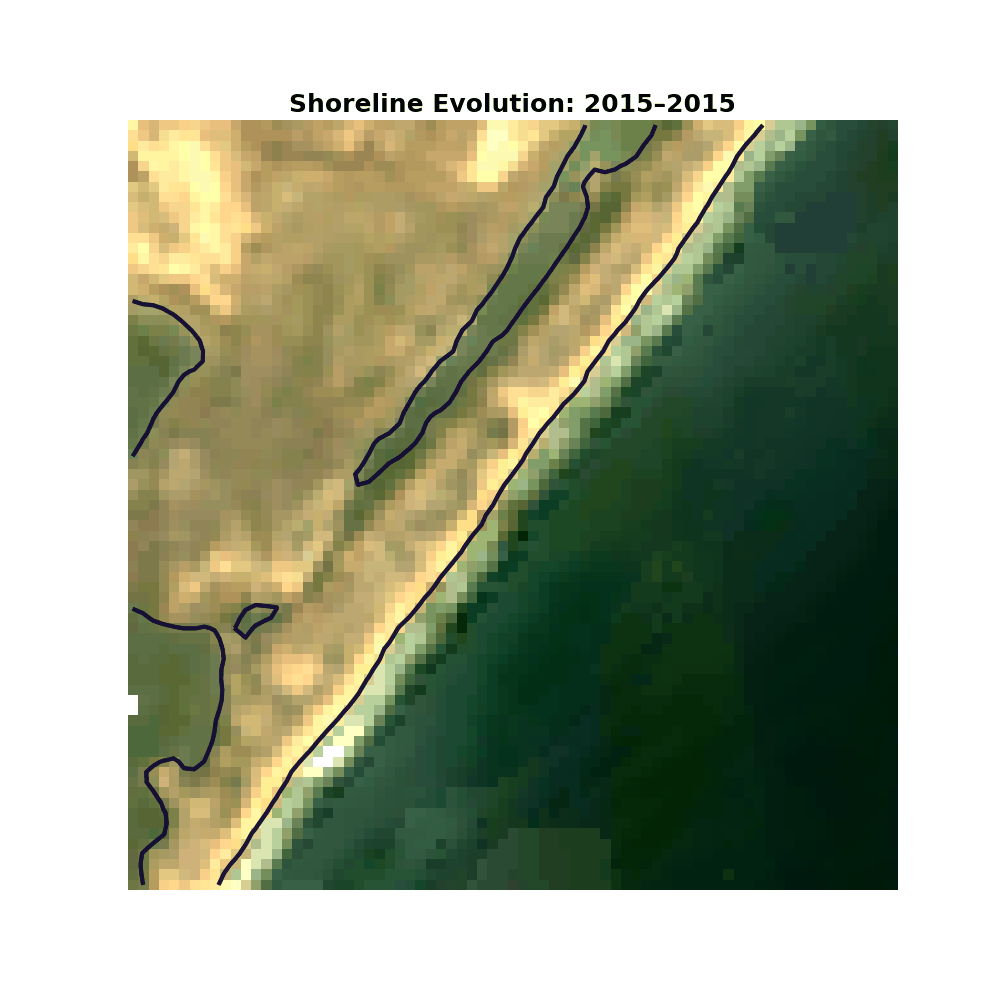

In [17]:
# Assuming your dataset is 'ds_selected' and your shorelines are 'contour_gdf' used generate_
cf.generate_shoreline_animation(
    ds_selected=ds_selected,
    contour_gdf=contour_gdf,
    time_step="1Y",
    output_file="Blekusu_Shoreline_2015_2024.gif"
)

In [18]:
client.close()

## Annual Variations Relative to Baseline Period 2015

This workflow extracts annual shoreline positions from Landsat imagery, computes shoreline movement relative to a baseline year (`2015`), and visualizes the results both as a static plot and an animated time series. Using the MNDWI water index, the script generates yearly shoreline contours, computes how far each later shoreline has retreated or advanced compared to `2015`, summarizes these changes, and exports both tabular and graphical outputs. It restructures results into a clean analytical table, calculates average annual shoreline change, and produces both a CSV summary and visual outputs including a static line plot and an animated GIF showing year-to-year shoreline movement.

In [19]:
# Reference Year
baseline_year = 2015

# Set the range of dates for the analysis, time step and tide range
time_range = ("2015", "2024")
time_step = "1Y"

# Load Landsat data only
ds, product_name = load_best_available_ds(dc, lat_range, lon_range, time_range,
                                          time_step, set_product="ls")

# Compute water index (MNDWI for Landsat)
ds = calculate_indices(ds, index="MNDWI", satellite_mission="ls")
var = "MNDWI"


No resolution pre-set, using default resolutions for individual products...

Pre-selected product: Landsat
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr
    ls9_sr
Counting good quality pixels for each time step
Filtering to 152 out of 245 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 152 time steps as a dask array


**Annual MNDWI Composite Generation**

This code block creates annual summary composites from the MNDWI time series to support year-by-year shoreline analysis. The dataset is resampled to the specified temporal step (e.g., yearly), and the median value is calculated across all observations within each period to reduce noise from clouds and outliers. The time coordinate is then converted to calendar years and renamed from `time` to `year`, producing a clean, year-indexed dataset suitable for long-term coastal change assessment.


In [20]:
# Annual composites originally median
ds_summaries = ds[[var]].resample(time=time_step).median("time").compute()
ds_summaries["time"] = ds_summaries.time.dt.year
ds_summaries = ds_summaries.rename(time="year")

**Sub-pixel Shoreline Extraction**

This code block extracts annual shorelines from the MNDWI composites using a sub-pixel contouring approach. It traces the zero-value contour of the MNDWI index, which represents the land–water boundary, for each year in the dataset. The resulting shorelines are converted into vector features with a specified coordinate reference system, filtered to remove overly simple geometries, and saved as a GeoJSON file. Finally, the extracted shorelines are indexed by year, making them ready for temporal analysis of shoreline change.


In [21]:
# Extract annual shorelines
contour_gdf = subpixel_contours(
    da=ds_summaries[var], z_values=0, dim="year",
    crs=ds_summaries.geobox.crs,
    output_path="extra_annual_shorelines_ls.geojson",
    min_vertices=15,
).set_index("year")

Operating in single z-value, multiple arrays mode
Writing contours to extra_annual_shorelines_ls.geojson


In [22]:
# Generate baseline shoreline points (2015)
points_gdf = points_on_line(contour_gdf, index=baseline_year, distance=30)

# Calculate distances to other years
points_gdf = annual_movements(points_gdf, contour_gdf, ds_summaries, baseline_year=baseline_year, water_index=var)


### Computation of Annual Shoreline Change Relative to Baseline

This code block processes shoreline–transect intersection results to quantify coastal change over time. It first selects all distance-to-shoreline columns, then reshapes the dataset from wide to long format to associate each distance measurement with its corresponding year. The year labels are cleaned and converted to integers, after which mean shoreline distance is calculated for each year. Finally, shoreline change is expressed relative to a defined baseline year by subtracting the baseline distance, producing a time series of average shoreline advance or retreat in meters.

Here also, you will reshape data into `year`, `distance` and `rate_change_m`. The organized data is then displayed to see

In [23]:
#import pandas as pd

# 1. Keep only the distance columns + geometry
dist_cols = [c for c in points_gdf.columns if c.startswith("dist_")]

# 2. Melt wide → long
df_long = points_gdf.melt(
    id_vars="geometry",
    value_vars=dist_cols,
    var_name="year",
    value_name="distance"
)

# 3. Clean up the 'year' column (remove "dist_" prefix and convert to int)
df_long["year"] = df_long["year"].str.replace("dist_", "", regex=False).astype(int)

# 4. Average distance per year
yearly_changes = df_long.groupby("year")["distance"].mean().reset_index()

# 5. Compute relative change compared to baseline year
baseline_year = 2015  # ← set to your baseline
baseline_val = yearly_changes.loc[yearly_changes["year"] == baseline_year, "distance"].values[0]
yearly_changes["relative_change_m"] = yearly_changes["distance"] - baseline_val

yearly_changes


,year,distance,relative_change_m
0,2015,0.000000,0.000000
1,2016,-1.874449,-1.874449
2,2017,2.506857,2.506857
3,2018,5.620245,5.620245
4,2019,11.053796,11.053796
5,2020,15.137755,15.137755
6,2021,21.410449,21.410449
7,2022,12.674449,12.674449
8,2023,8.258408,8.258408
9,2024,14.742612,14.742612


In [24]:
# Save to CSV
yearly_changes.to_csv("shoreline_changes.csv", index=False)


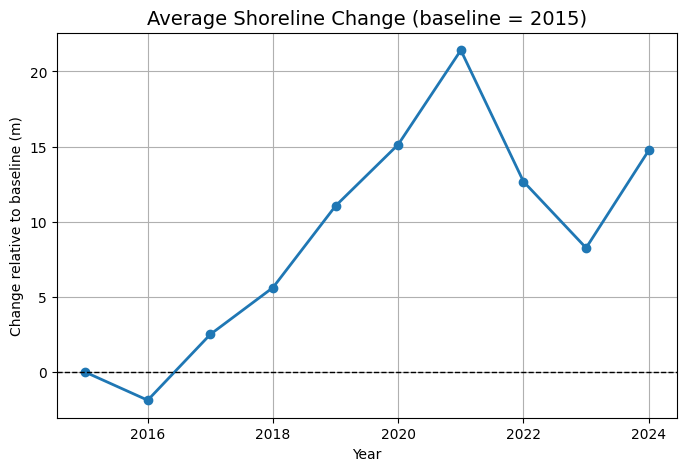

In [25]:
# Plot the average annual shoreline change relative to the baseline year
# and save the figure as a high-resolution PNG

plt.figure(figsize=(8,5))
plt.plot(yearly_changes["year"], yearly_changes["relative_change_m"], marker="o", linewidth=2)
plt.axhline(0, color="k", linestyle="--", lw=1)
plt.title(f"Average Shoreline Change (baseline = {baseline_year})", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Change relative to baseline (m)")
plt.grid(True)

#plt.show()
plt.savefig("shoreline_change.png", dpi=300, bbox_inches="tight")

### Animation of Annual Changes of Shoreline 

Here you can save your yearly shoreline changes as an animation of an interactive presentation 

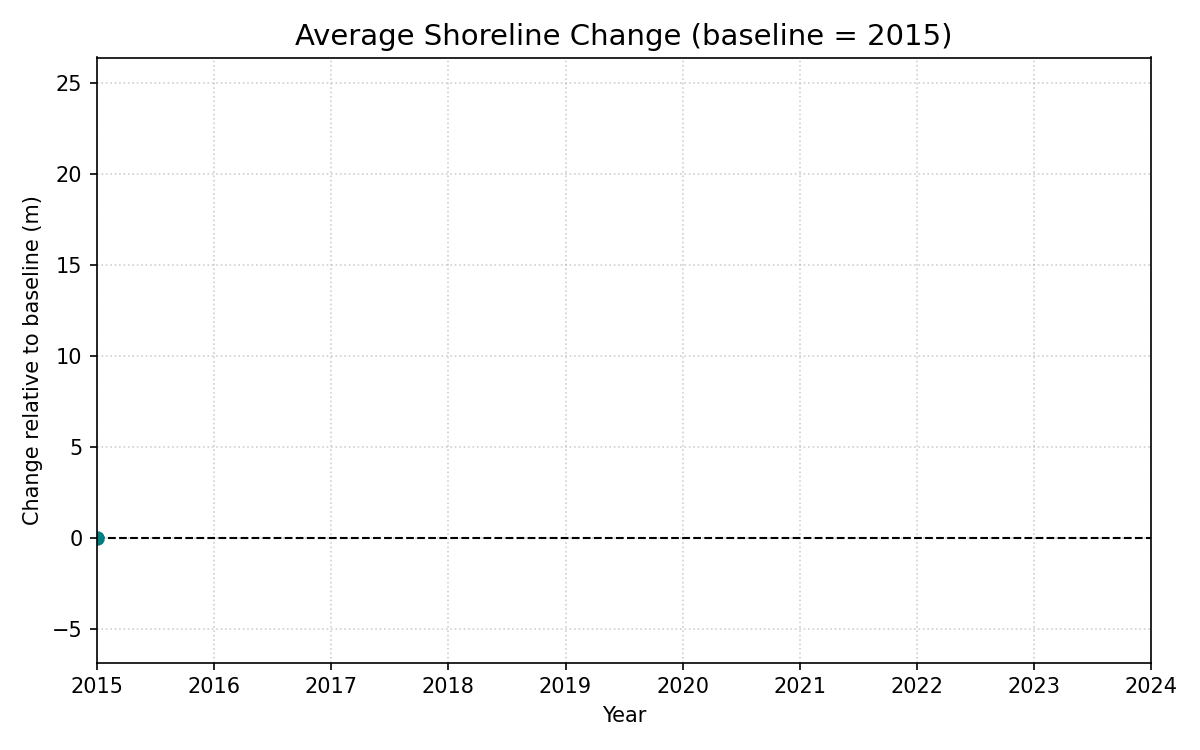

In [26]:
# Data
years = yearly_changes["year"].astype(int).tolist()
values = yearly_changes["relative_change_m"].tolist()

# --- Create figure ---
fig, ax = plt.subplots(figsize=(8,5))
ax.axhline(0, color="k", linestyle="--", lw=1)
line, = ax.plot([], [], marker="o", linewidth=2, color="teal")
ax.set_xlim(min(years), max(years))
ax.set_ylim(min(values)-5, max(values)+5)
ax.set_xlabel("Year")
ax.set_ylabel("Change relative to baseline (m)")
ax.set_title(f"Average Shoreline Change (baseline = {baseline_year})", fontsize=14)
ax.grid(True, linestyle=":", alpha=0.6)

def init():
    line.set_data([], [])
    return line,

def update(frame):
    x = years[:frame+1]
    y = values[:frame+1]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=len(years), init_func=init,
                    blit=True, interval=500, repeat=False)

plt.tight_layout()

# --- Save animation ---
ani.save("shoreline_change_yearly.gif", writer="pillow", dpi=150)
plt.close(fig)
# Display animation in 
Image(filename="shoreline_change_yearly.gif")

# Trend Analysis of Shoreline Changes using Linear Regression and Mann-Kendall Trend Test

## **Trend Analysis of Annual Shoreline Change Using Linear regression** 

This analysis quantifies the long-term trend in shoreline movement by fitting a **simple linear regression model** to the annual shoreline change data. The analysis uses **year** as the independent variable and **relative shoreline change (m)** as the dependent variable. The slope of the fitted regression line represents the **Linear Regression Rate (LRR)**, which estimates the average annual rate of shoreline movement in **metres per year (m/year)**.

In addition to estimating the rate of change, the analysis computes the **coefficient of determination (R²)** to evaluate how well the linear model explains the observed variability, the **p-value** to assess the statistical significance of the trend, and the **standard error** of the estimated slope. A positive slope indicates long-term **shoreline advance (accretion)**, whereas a negative slope indicates long-term **shoreline retreat (erosion)**.

The resulting plot displays the observed annual shoreline changes together with the fitted regression trend line, providing a visual assessment of the long-term shoreline evolution over the study period. This approach is widely used in coastal change assessments and is consistent with the **Linear Regression Rate (LRR)** methodology employed in shoreline monitoring studies such as the **USGS Digital Shoreline Analysis System (DSAS)** and **Digital Earth Africa Coastlines (DEA Coastlines)**.


**Key Steps**

* Extract the independent (year) and dependent (shoreline change) variables from the DataFrame.
* Perform linear regression that estimates, the slope, intercept, r2 value, p-value and standard error
* Compute the fitted shoreline from the linear equation **y = intercept + slope × year**
* Plot observed shoreline change and regression trend line

In [27]:
x = yearly_changes["year"]
y = yearly_changes["relative_change_m"]   # Use "distance" if preferred

# ------------------------------------------------------------
# Perform linear regression.
# ------------------------------------------------------------
result = linregress(x, y)

# Extract regression statistics
slope = result.slope         #   slope      -> Rate of shoreline change (m/year)
intercept = result.intercept #   intercept  -> Regression intercept
r2 = result.rvalue**2        #   rvalue     -> Correlation coefficient
p_value = result.pvalue      #   pvalue     -> Significance of the trend
std_err = result.stderr      #   stderr     -> Standard error of the slope

The next steps is to 
* Compute the fitted shorine using the linear regression equation,
* Print the statistics and
* interpret the output

In [28]:
# ------------------------------------------------------------
# Compute the fitted (predicted) shoreline positions using the regression equation:
#       y = intercept + slope × year
# ------------------------------------------------------------
trend = intercept + slope * x

# ------------------------------------------------------------
# Display regression statistics
# ------------------------------------------------------------
print("=" * 50)
print("LINEAR REGRESSION TREND ANALYSIS")
print("=" * 50)
print(f"Slope (Rate of Change): {slope:.3f} m/year")
print(f"Coefficient of Determination (R²): {r2:.3f}")
print(f"P-value              : {p_value:.4f}")
print(f"Standard Error       : {std_err:.3f}")

# ------------------------------------------------------------
# Interpret the statistical significance
# ------------------------------------------------------------
if p_value < 0.05:
    print("\nTrend is statistically significant (p < 0.05).")
else:
    print("\nTrend is NOT statistically significant (p ≥ 0.05).")

# ------------------------------------------------------------
# Interpret shoreline movement direction positive means accretion,
# negative means erosion
# ------------------------------------------------------------
if slope > 0:
    print(f"Average shoreline advance (accretion): {slope:.2f} m/year") 
elif slope < 0:
    print(f"Average shoreline retreat (erosion): {abs(slope):.2f} m/year")
else:
    print("No long-term shoreline change detected.")

LINEAR REGRESSION TREND ANALYSIS
Slope (Rate of Change): 1.854 m/year
Coefficient of Determination (R²): 0.572
P-value              : 0.0114
Standard Error       : 0.567

Trend is statistically significant (p < 0.05).
Average shoreline advance (accretion): 1.85 m/year


### **Plot Shoreline Changes with trend lines**

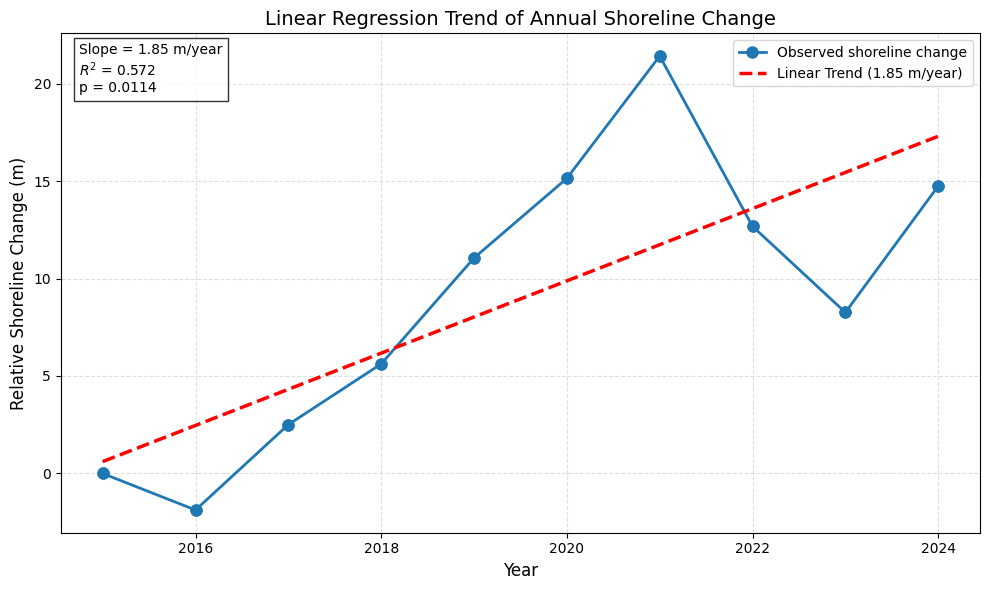

In [29]:
# ============================================================
# Plot observed shoreline change and regression trend line
# ============================================================
plt.figure(figsize=(10, 6))

# Plot observed shoreline changes
plt.plot(x, y, marker="o", linewidth=2, markersize=8, label="Observed shoreline change")

# Plot fitted regression line
plt.plot(x, trend, "r--", linewidth=2.5, label=f"Linear Trend ({slope:.2f} m/year)")

# Overlay observation points
plt.scatter(x, y, s=60)

# Axis labels and title
plt.xlabel("Year", fontsize=12)
plt.ylabel("Relative Shoreline Change (m)", fontsize=12)
plt.title("Linear Regression Trend of Annual Shoreline Change", fontsize=14)

# Add grid and legend
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

# ------------------------------------------------------------
# Display regression statistics on the plot
# ------------------------------------------------------------
plt.text(0.02, 0.98, f"Slope = {slope:.2f} m/year\n" f"$R^2$ = {r2:.3f}\n" f"p = {p_value:.4f}",
    transform=plt.gca().transAxes, verticalalignment="top", 
         bbox=dict(facecolor="white", edgecolor="black", alpha=0.8))

# Improve layout and display the figure
plt.tight_layout()
plt.show()

### **Mann–Kendall Trend Analysis of Annual Shoreline Change**

This analysis evaluates the presence of a long-term monotonic trend in annual shoreline change using the **Mann–Kendall (MK) trend test**, a non-parametric statistical method that does not require the data to be normally distributed or linearly related. The MK test assesses whether shoreline positions exhibit a statistically significant increasing or decreasing trend over time by computing **Kendall's Tau (τ)**, the **Z statistic**, and the associated **p-value**.

To quantify the magnitude of the detected trend, the analysis reports **Sen's Slope**, a robust non-parametric estimator of the median annual rate of shoreline change (m/year). A positive Sen's Slope indicates long-term shoreline advance (accretion), whereas a negative value indicates shoreline retreat (erosion).

For visualization purposes, an **ordinary least squares (OLS) linear trend line** is superimposed on the observed shoreline change time series. The OLS line is included solely to illustrate the overall direction of change and is **not** used in the Mann–Kendall statistical test. Trend significance is determined exclusively from the Mann–Kendall test statistics, while Sen's Slope provides the corresponding rate of change. This combination of the Mann–Kendall test and Sen's Slope is widely applied in hydrological, climatological, and coastal change studies because of its robustness to non-normal data, outliers, and non-linear variability.

**First:** Install the pymannkendall module for Mann-Kendall Trend Analysis 

In [30]:
pip install pymannkendall # install Mann-Kendall Module


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


**Key Steps**

* Extract the independent (year) and dependent (shoreline change)variables from the DataFrame.
* Perform Mann-Kendall Trend Test, that estimates, the trend, p-value, Z statistics, Kendall Tau and Sen's Slope 
* Compute the fitted shoreline from the linear equation **y = intercept + slope × year**
* Plot observed shoreline change and regression trend line

In [31]:
# Import the Mann-Kendall Function for the trend analysis
import pymannkendall as mk     

# ============================================================
# Extract variables and Perform Mann-Kendall Trend Test
# ============================================================

# ------------------------------------------------------------
# Extract variables
# ------------------------------------------------------------
x = yearly_changes["year"]
y = yearly_changes["relative_change_m"]

# ------------------------------------------------------------
# Mann-Kendall Trend Test
# ------------------------------------------------------------
mk_result = mk.original_test(y)

# ------------------------------------------------------------
# Linear regression (for visualization only)
# ------------------------------------------------------------
reg = linregress(x, y)
trend_line = reg.intercept + reg.slope * x

# ------------------------------------------------------------
# Print Mann-Kendall results
# ------------------------------------------------------------
print("=" * 60)
print("MANN-KENDALL TREND TEST")
print("=" * 60)

print(f"Trend          : {mk_result.trend}")
print(f"P-value        : {mk_result.p:.4f}")
print(f"Z statistic    : {mk_result.z:.3f}")
print(f"Kendall Tau    : {mk_result.Tau:.3f}")
print(f"Sen's Slope    : {mk_result.slope:.3f} m/year")


MANN-KENDALL TREND TEST
Trend          : increasing
P-value        : 0.0200
Z statistic    : 2.326
Kendall Tau    : 0.600
Sen's Slope    : 1.873 m/year


### **Plot Shoreline Changes with trend lines**

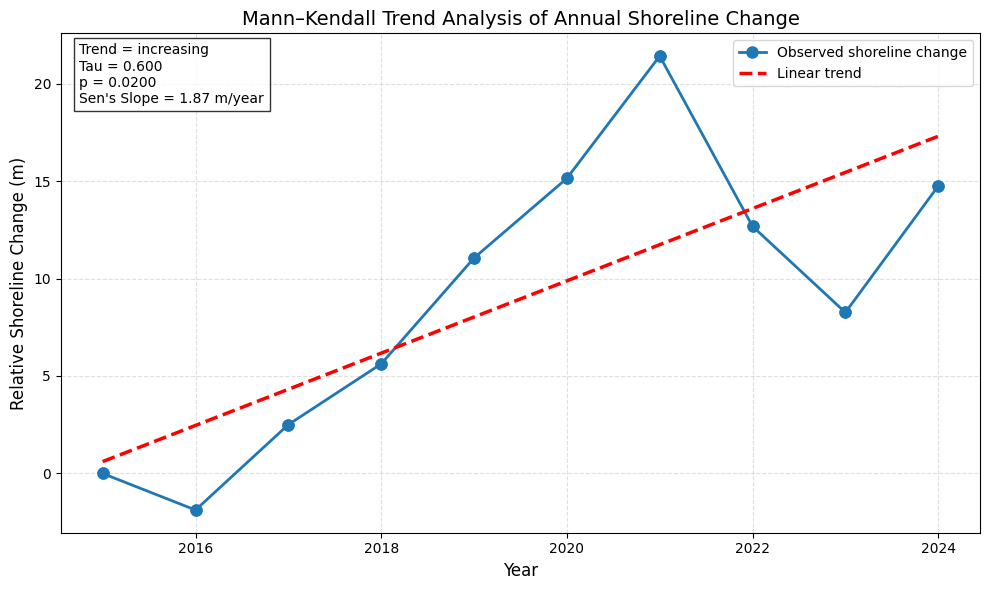

In [32]:
# ------------------------------------------------------------
# Plot observed shoreline change and regression trend line
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

# Observed shoreline change
plt.plot(x, y, marker='o', linewidth=2, markersize=8, label='Observed shoreline change')

# Linear trend line (visualization only)
plt.plot(x, trend_line,'r--', linewidth=2.5, label='Linear trend')

plt.scatter(x, y, s=60)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Relative Shoreline Change (m)", fontsize=12)
plt.title("Mann–Kendall Trend Analysis of Annual Shoreline Change", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.4)

# Annotate Mann-Kendall statistics
plt.text(0.02, 0.98, f"Trend = {mk_result.trend}\n" f"Tau = {mk_result.Tau:.3f}\n" f"p = {mk_result.p:.4f}\n"
    f"Sen's Slope = {mk_result.slope:.2f} m/year",
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)

plt.legend()
plt.tight_layout()
plt.show()